# Shifting Detector

In [1]:
import argparse
import time
import os
import numpy as np
import pandas as pd
import torch
import sys
import AdaLQO.utils as utils
import AdaLQO.shift_detector as shift_detector

# from utils import *

sys.path.insert(0, 'bao_server')
import bao_server.model as model
import copy
import random

sys.path.append('ShiftHandler')
from replay_buffer import summarizer

## 1. Load DataSet

### 1.1 load all datasets - queries, plans, latecies

In [2]:

df = utils.load_data("tpc-h-shifting")
BATCH_SIZE = 20
data = utils.split_dataset(df, batch_size=BATCH_SIZE)

In [3]:
X, y = utils.get_training_data(data[0][0])

## 2. Training BAO Model

In [4]:
# TODO:// have_cache_data=False, since Buffer Feature missed. Fix it later
reg = model.BaoRegression(have_cache_data=False, verbose=False)
try:
    reg.fit_feature_extractor(X, y)
except Exception as e:
    print("ERROR:", e)

In [5]:
reg.fit_model(X, y, seed=42, ada_size=False)

([tensor(122),
  tensor(248),
  tensor(84),
  tensor(67),
  tensor(110),
  tensor(130),
  tensor(1),
  tensor(18),
  tensor(246),
  tensor(39),
  tensor(138),
  tensor(228),
  tensor(54),
  tensor(206),
  tensor(23),
  tensor(192),
  tensor(207),
  tensor(21),
  tensor(167),
  tensor(155),
  tensor(249),
  tensor(125),
  tensor(197),
  tensor(46),
  tensor(63),
  tensor(243),
  tensor(73),
  tensor(81),
  tensor(131),
  tensor(66),
  tensor(212),
  tensor(171),
  tensor(99),
  tensor(222),
  tensor(32),
  tensor(20),
  tensor(47),
  tensor(50),
  tensor(186),
  tensor(112),
  tensor(106),
  tensor(185),
  tensor(3),
  tensor(69),
  tensor(191),
  tensor(11),
  tensor(149),
  tensor(234),
  tensor(153),
  tensor(13),
  tensor(170),
  tensor(213),
  tensor(102),
  tensor(251),
  tensor(204),
  tensor(109),
  tensor(255),
  tensor(43),
  tensor(160),
  tensor(164),
  tensor(126),
  tensor(198),
  tensor(136),
  tensor(15),
  tensor(258),
  tensor(256),
  tensor(87),
  tensor(217),
  tenso

## 3. Predict Other Group Data

In [6]:
def embedding_plans(model, batch):
    all_plans = []
    for plans in batch["plans"]:
        all_plans.extend(plans)
    trees = model._BaoRegression__tree_transform.transform(all_plans)
    return model._BaoRegression__net.get_fixed_features(trees)

In [7]:
import pandas as pd
from AdaLQO.utils import prediction
from AdaLQO.shift_detector import mmd
res = []
base_data = data[0][0]
base_embedding = embedding_plans(reg,base_data)
pre_data = data[0][0]
ori_reg = copy.deepcopy(reg)

for i, phase in enumerate(data):
    for j, batch in enumerate(phase):
        # Skip  the first batch
        if i+j == 0:
            continue
        cur_embedding = embedding_plans(reg, batch)
        mmd_score = mmd(cur_embedding, base_embedding)
        print(i, j, mmd_score)
        # if detected shifting, retrain Bao Model with the last batch data
        if mmd_score > 0.03:
            base_data = pre_data
            X, y = utils.get_training_data(base_data)
            try:
                reg.fit_feature_extractor(X, y)
            except Exception as e:
                print("ERROR:", e)
            reg.fit_model(X, y, seed=42, ada_size=False)
            base_embedding = embedding_plans(reg,base_data)

        ori_res = prediction(ori_reg, batch)
        cur_res = prediction(reg,batch)
        cur_res["base_bao_latency"] = ori_res["bao_latency"]
        res.append(cur_res)
        pre_data = data[i][j]

0 1 tensor(0.0278, device='cuda:0', grad_fn=<AddBackward0>)
1 0 tensor(0.0614, device='cuda:0', grad_fn=<AddBackward0>)
1 1 tensor(0.0315, device='cuda:0', grad_fn=<AddBackward0>)
2 0 tensor(0.0319, device='cuda:0', grad_fn=<AddBackward0>)
2 1 tensor(0.0491, device='cuda:0', grad_fn=<AddBackward0>)


In [8]:
res_df = pd.concat(res,ignore_index=True)

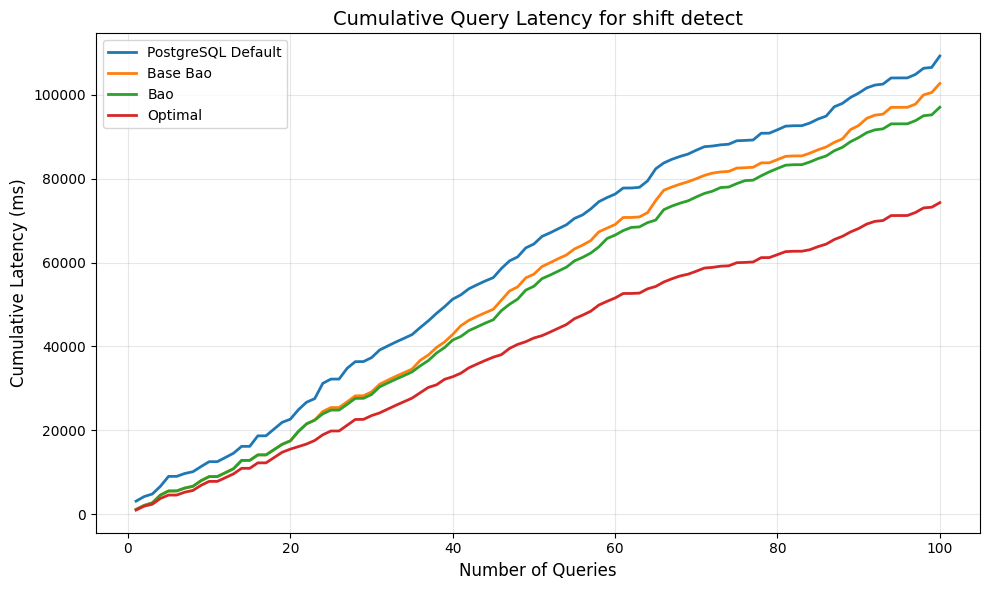

In [11]:
from AdaLQO.utils import plot_res
plot_res("shift detect",res_df,"results/detector_performance.png")

因此我建议最终论文主图用：
Normalized Latency (Default/Bao/Optimal) ← 主图
Regret vs Phase ← 核心结果
MMD Score + Retrain Point ← 方法验证
Top-1 Accuracy ← 辅助结果
这四张图基本就能完整支撑整个 Continual LQO 论文的实验部分。

## 4. Queries(Plans) Featurization

## 5. Maximum Mean Discrepancy (MMD)

## 6. Relationship of MMD score & Regret

In [ ]:
res_1 = prediction(p1_df)
regrets_1 = res["regret"]
res_2 = prediction(p2_df)
regrets_2 = res["regret"]

In [ ]:
import matplotlib.pyplot as plt

x_np = [t.item() for t in mmd_score_p1]
y_np = list(regrets_1)

# 3. Create the scatter plot
plt.scatter(x_np, y_np)
plt.xlabel("MMD Score P1")
plt.ylabel("Regrets")
plt.show()

## 7. K-S test vs regret

In [ ]:
print(type(emb_p0))
embedding_p0 = emb_p0.cpu().detach().numpy()
print(type(embedding_p0))

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
ks_stat_p1 = []
ks_p_values_p1 = []
p1_plans = p2_df["plans"]
# PCA到1维
phase0_1d = pca.fit_transform(embedding_p0)


for p in p1_plans:
    trees = reg._BaoRegression__tree_transform.transform(p)
    embedding = reg._BaoRegression__net.get_fixed_features(trees).cpu().detach().numpy()
    phase1_1d = pca.transform(embedding)
    ks_stat_i, p_i = ks_2samp(phase0_1d[:,0], phase1_1d[:,0])
    ks_stat_p1.append(ks_stat_i)
    ks_p_values_p1.append(p_i)

## 8. KL-Divergence Or JSD vs Regrets (Optional)

## 9. Wassertein Distance vs Regrets